In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
ad_df=pd.read_csv("Advertising.csv")
ad_df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [17]:
X=ad_df[['TV']]
y=ad_df['Sales']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
y_pred = model.predict(X_test)

In [21]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [22]:
print("--- Model Parameters ---")
print(f"Slope (b1 / Coefficient): {model.coef_[0]:.4f}")
print(f"Intercept (b0):           {model.intercept_:.4f}")

print("\n--- Model Evaluation ---")
print(f"MAE:      {mae:.4f}")
print(f"MSE:      {mse:.4f}")
print(f"RMSE:     {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

--- Model Parameters ---
Slope (b1 / Coefficient): 0.0465
Intercept (b0):           7.1196

--- Model Evaluation ---
MAE:      2.4444
MSE:      10.2047
RMSE:     3.1945
R² Score: 0.6767


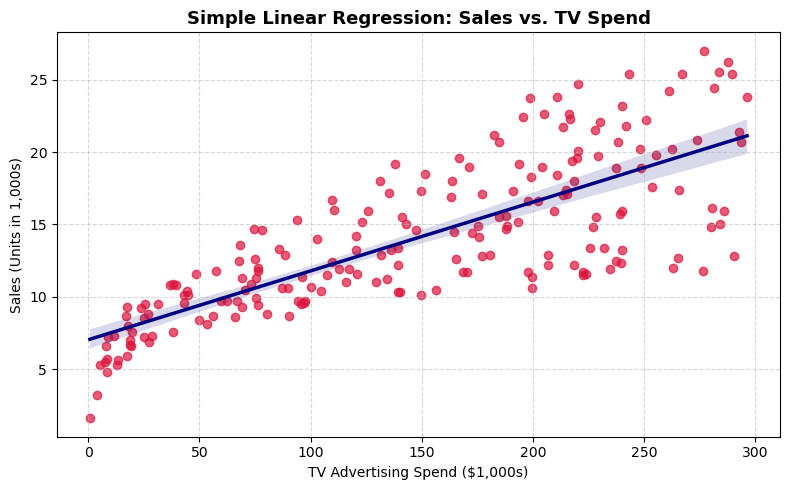

In [27]:
plt.figure(figsize=(8, 5))
sns.regplot(x='TV', y='Sales', data=ad_df, 
            scatter_kws={'color': 'crimson', 'alpha': 0.7}, 
            line_kws={'color': 'navy', 'linewidth': 2.5})

plt.title('Simple Linear Regression: Sales vs. TV Spend', fontsize=13, fontweight='bold')
plt.xlabel('TV Advertising Spend ($1,000s)')
plt.ylabel('Sales (Units in 1,000s)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [29]:
# Define hypothetical TV advertising budgets (in $1,000s)
new_budgets = pd.DataFrame({'TV': [1000, 150, 250]})

# Predict expected sales
predicted_sales = model.predict(new_budgets)

# Display predictions
for budget, sales in zip(new_budgets['TV'], predicted_sales):
    print(f"If TV Budget is ${budget},000  -->  Predicted Sales: {sales:.2f}k units")

If TV Budget is $1000,000  -->  Predicted Sales: 53.65k units
If TV Budget is $150,000  -->  Predicted Sales: 14.10k units
If TV Budget is $250,000  -->  Predicted Sales: 18.75k units
